In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(
    "../data/processed/student_performance_engineered.csv"
)

df.head()

,weekly_self_study_hours,attendance_percentage,class_participation,study_attendance_interaction,engagement_score,total_score
0,18.5,95.6,3.8,1768.60,49.70,97.9
1,14.0,80.0,2.5,1120.00,41.25,83.9
2,19.5,86.3,5.3,1682.85,45.80,100.0
3,25.7,70.2,7.0,1804.14,38.60,100.0
4,13.4,81.9,6.9,1097.46,44.40,92.0


In [8]:
features = [
    "weekly_self_study_hours",
    "attendance_percentage",
    "class_participation"
]

X = df[features]
y = df["total_score"]

In [6]:
print("Dataset shape:", df.shape)
print(df.columns.tolist())

Dataset shape: (5010, 6)
['weekly_self_study_hours', 'attendance_percentage', 'class_participation', 'study_attendance_interaction', 'engagement_score', 'total_score']


In [9]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5010, 3)
y shape: (5010,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [11]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (4008, 3)
Testing features: (1002, 3)
Training target: (4008,)
Testing target: (1002,)


In [12]:
scaler = StandardScaler()

In [13]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
print("Scaled training data:")
print(X_train_scaled[:5])

Scaled training data:
[[-0.28339271  0.15119074  0.10670081]
 [-0.25410155  1.49843785 -0.40096403]
 [ 1.2104565   0.42919412  0.30976675]
 [-0.94244384 -2.63953541  0.61436566]
 [ 0.87360815  1.31666642  1.4773959 ]]


In [15]:
print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Training shape: (4008, 3)
Testing shape: (1002, 3)


In [16]:
model = LinearRegression()

model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[12.37,-0.22,-0.2 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,84.66
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[64.6 ,63.19,62.12]"


In [17]:
y_pred = model.predict(X_test_scaled)

In [18]:
print("Actual values:")
print(y_test.head(10).values)

print("\nPredicted values:")
print(y_pred[:10])

Actual values:
[ 98.7 100.   98.8 100.   71.7  60.7  85.6  82.4  82.1 100. ]

Predicted values:
[ 90.84471526 103.9320135   88.42865308  99.12343794  75.58432972
  57.27254099  84.30272513  79.85915086  76.64577934  96.69949086]


In [19]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-----------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Model Performance
-----------------
MAE : 7.338116812776873
RMSE: 9.256939085418178
R²  : 0.6505959778931936


In [20]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)

tree_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``

In [21]:
tree_pred = tree_model.predict(X_test)

In [22]:
tree_mae = mean_absolute_error(y_test, tree_pred)
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_pred))
tree_r2 = r2_score(y_test, tree_pred)

print("Decision Tree Performance")
print("------------------------")
print("MAE :", tree_mae)
print("RMSE:", tree_rmse)
print("R²  :", tree_r2)

Decision Tree Performance
------------------------
MAE : 6.2210539128414455
RMSE: 8.471164162946446
R²  : 0.7073966565916049


In [23]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of t

In [24]:
rf_pred = rf_model.predict(X_test)

In [25]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Performance")
print("-------------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Performance
-------------------------
MAE : 6.197973370355305
RMSE: 8.45846241355023
R²  : 0.7082734635887109


In [26]:
engineered_features = [
    "weekly_self_study_hours",
    "attendance_percentage",
    "class_participation",
    "study_attendance_interaction",
    "engagement_score"
]

X_engineered = df[engineered_features]
y = df["total_score"]

print("X_engineered shape:", X_engineered.shape)

X_engineered shape: (5010, 5)


In [27]:
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_engineered,
    y,
    test_size=0.20,
    random_state=42
)

print("Training shape:", X_train_eng.shape)
print("Testing shape:", X_test_eng.shape)

Training shape: (4008, 5)
Testing shape: (1002, 5)


In [28]:
rf_eng_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

rf_eng_model.fit(X_train_eng, y_train_eng)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of t

In [29]:
rf_eng_pred = rf_eng_model.predict(X_test_eng)

In [30]:
rf_eng_mae = mean_absolute_error(y_test_eng, rf_eng_pred)
rf_eng_rmse = np.sqrt(mean_squared_error(y_test_eng, rf_eng_pred))
rf_eng_r2 = r2_score(y_test_eng, rf_eng_pred)

print("Random Forest with Engineered Features")
print("--------------------------------------")
print("MAE :", rf_eng_mae)
print("RMSE:", rf_eng_rmse)
print("R²  :", rf_eng_r2)

Random Forest with Engineered Features
--------------------------------------
MAE : 6.193381320894927
RMSE: 8.444556397952256
R²  : 0.7092318928736445


In [31]:
residuals = y_test_eng - rf_eng_pred

print("Residual statistics:")
print(residuals.describe())

Residual statistics:
count    1002.000000
mean       -0.358377
std         8.441162
min       -29.094383
25%        -4.847846
50%         0.300447
75%         4.539675
max        28.280577
Name: total_score, dtype: float64


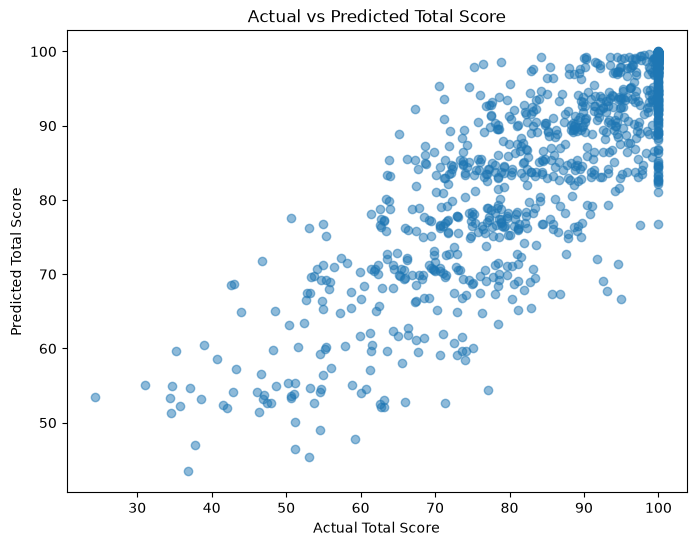

In [32]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test_eng, rf_eng_pred, alpha=0.5)

plt.xlabel("Actual Total Score")
plt.ylabel("Predicted Total Score")
plt.title("Actual vs Predicted Total Score")

plt.show()

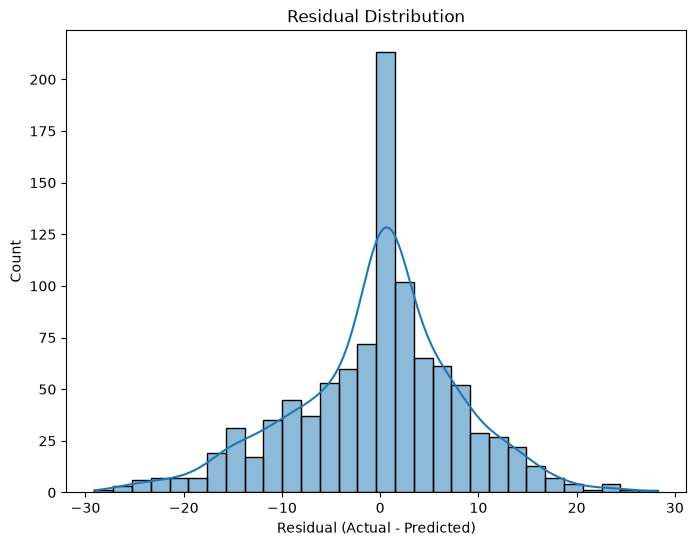

In [33]:
plt.figure(figsize=(8, 6))

sns.histplot(residuals, bins=30, kde=True)

plt.xlabel("Residual (Actual - Predicted)")
plt.title("Residual Distribution")

plt.show()

In [34]:
absolute_errors = np.abs(y_test_eng - rf_eng_pred)

print("Mean Absolute Error:", absolute_errors.mean())
print("Maximum Error:", absolute_errors.max())

Mean Absolute Error: 6.193381320894927
Maximum Error: 29.094383140595017


In [35]:
print("Residual mean:", residuals.mean())
print("Residual median:", residuals.median())
print("Residual standard deviation:", residuals.std())

print("\nLargest absolute errors:")
print(
    pd.DataFrame({
        "actual": y_test_eng.values,
        "predicted": rf_eng_pred,
        "residual": residuals.values,
        "absolute_error": absolute_errors
    })
    .sort_values("absolute_error", ascending=False)
    .head(10)
)

Residual mean: -0.3583771290906646
Residual median: 0.3004472572870043
Residual standard deviation: 8.44116162498652

Largest absolute errors:
      actual  predicted   residual  absolute_error
2344    24.3  53.394383 -29.094383       29.094383
3983    95.0  66.719423  28.280577       28.280577
1505    50.6  77.526686 -26.926686       26.926686
3058    42.6  68.576745 -25.976745       25.976745
533     43.0  68.731948 -25.731948       25.731948
4897    93.1  67.780649  25.319351       25.319351
96      67.3  92.317154 -25.017154       25.017154
3951    46.8  71.733490 -24.933490       24.933490
1438    70.5  95.322366 -24.822366       24.822366
2299    35.2  59.712099 -24.512099       24.512099


In [36]:
error_analysis = pd.DataFrame({
    "actual": y_test_eng.values,
    "predicted": rf_eng_pred
})

error_analysis["absolute_error"] = (
    np.abs(error_analysis["actual"] - error_analysis["predicted"])
)

error_analysis["score_group"] = pd.cut(
    error_analysis["actual"],
    bins=[0, 60, 80, 100],
    labels=["Low", "Medium", "High"]
)

print(
    error_analysis
    .groupby("score_group", observed=True)["absolute_error"]
    .agg(["count", "mean", "max"])
)

             count       mean        max
score_group                             
Low             81  11.459866  29.094383
Medium         280   8.051502  25.017154
High           641   4.716222  28.280577


In [38]:
from sklearn.model_selection import cross_val_score

In [39]:
cv_scores = cross_val_score(
    rf_eng_model,
    X_engineered,
    y,
    cv=5,
    scoring="r2"
)

print("Cross-validation R² scores:")
print(cv_scores)

print("\nMean CV R²:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

Cross-validation R² scores:
[0.68532916 0.6975328  0.70298666 0.71437936 0.71321166]

Mean CV R²: 0.7026879266563245
Standard deviation: 0.01072781395698492


In [40]:
feature_importance = pd.DataFrame({
    "feature": engineered_features,
    "importance": rf_eng_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

print(feature_importance)

                        feature  importance
0       weekly_self_study_hours    0.896014
3  study_attendance_interaction    0.033837
4              engagement_score    0.025546
2           class_participation    0.024179
1         attendance_percentage    0.020424


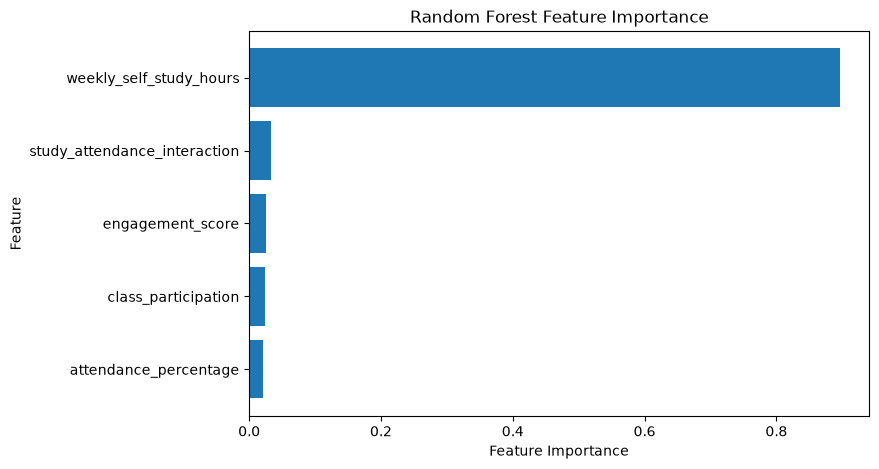

In [41]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [42]:
print(feature_importance.to_string(index=False))

                     feature  importance
     weekly_self_study_hours    0.896014
study_attendance_interaction    0.033837
            engagement_score    0.025546
         class_participation    0.024179
       attendance_percentage    0.020424


In [43]:
import joblib

joblib.dump(
    rf_eng_model,
    "../models/random_forest_student_performance.pkl"
)

print("Final model saved successfully.")

Final model saved successfully.


In [44]:
joblib.dump(
    engineered_features,
    "../models/feature_names.pkl"
)

print("Feature names saved successfully.")

Feature names saved successfully.


In [45]:
import joblib

model = joblib.load(
    "../models/random_forest_student_performance.pkl"
)

print(type(model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [46]:
features = joblib.load(
    "../models/feature_names.pkl"
)

print(features)

['weekly_self_study_hours', 'attendance_percentage', 'class_participation', 'study_attendance_interaction', 'engagement_score']
